# NextBuy — Des Données Brutes aux Décisions Intelligentes

**Objectif :** Explorer un jeu de données réel de courses alimentaires (des millions de commandes, des milliers de clients) pour en extraire des analyses exploitables pour l’entreprise et construire des modèles prédictifs de ML.

**Démarche :**
1. **Chargement & Nettoyage des données** — Combiner, nettoyer et fusionner les fichiers CSV bruts en un seul master dataset.
2. **Analyse Exploratoire des Données (EDA)** — Répondre à 10 questions business avec des visualisations variées et appropriées.
3. **Feature Engineering** — Créer 50+ features capturant le comportement utilisateur, la popularité des produits et les interactions.
4. **Modélisation Prédictive** — Entraîner et comparer Random Forest vs LightGBM pour prédire les rachats de produits.
5. **Conclusions & Recommandations** — Synthétiser les résultats clés et les stratégies business.

---

## 1. Configuration & Imports

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score
)

try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print('LightGBM version:', lgb.__version__)
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed — falling back to sklearn GradientBoostingClassifier.')
    print('To install: pip install lightgbm')
    from sklearn.ensemble import GradientBoostingClassifier

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
COLORS = ['#3A86FF', '#FF006E', '#8338EC', '#FB5607', '#06D6A0', '#FFD166', '#118AB2', '#073B4C']

print('Tous les imports réussis.')
print('Répertoire de travail :', os.getcwd())

LightGBM version: 4.6.0
Tous les imports réussis.
Répertoire de travail : /home/pramet/Documents/second_semestre_project/next_buy/B-DAT-201-LYN-2-1-nextbuy-4


---
## 2. Chargement & Nettoyage des Données

Nous partons de 5 fichiers CSV bruts :
- `aisles.csv` — noms des rayons (134 rayons)
- `departments.csv` — noms des départements (21 départements)
- `products.csv` — catalogue produits (~49k produits)
- `orders.csv` — métadonnées des commandes (utilisateur, horaires, séquence)
- `order_products.csv` — articles de chaque commande (~33M lignes)

Nous les fusionnons en un seul **master dataset** où chaque ligne = un produit dans une commande, enrichi avec les informations utilisateur, produit, rayon et département.

### 2.1 Catalogue Produits

In [2]:
# Chargement des tables de référence
df_products = pd.read_csv('products.csv')
df_aisles = pd.read_csv('aisles.csv')
df_departments = pd.read_csv('departments.csv')

print(f'Products:    {len(df_products):>7,} rows')
print(f'Aisles:      {len(df_aisles):>7,} rows')
print(f'Departments: {len(df_departments):>7,} rows')

# Construction du catalogue par fusion produit / aisle / department
df_catalog = (
    df_products
    .merge(df_aisles, on='aisle_id', how='left')
    .merge(df_departments, on='department_id', how='left')
)

print(f'\nCatalog shape: {df_catalog.shape}')
print(f'Missing values:\n{df_catalog.isnull().sum()}')
df_catalog.head(3)

Products:     49,688 rows
Aisles:          134 rows
Departments:      21 rows

Catalog shape: (49688, 6)
Missing values:
product_id       0
product_name     0
aisle_id         0
department_id    0
aisle            0
department       0
dtype: int64


,product_id,product_name,aisle_id,department_id,aisle,department
0,1,Chocolate Sandwich Cookies,61,19,cookies cakes,snacks
1,2,All-Seasons Salt,104,13,spices seasonings,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,tea,beverages


### 2.2 Historique des Commandes

In [3]:
# Chargement des commandes — gestion des problèmes d'en-tête
expected_cols = ['order_id', 'user_id', 'order_number', 'order_dow',
                 'order_hour_of_day', 'days_since_prior_order']

df_orders = pd.read_csv('orders.csv')

# Si les colonnes ne correspondent pas, recharger avec des noms explicites
if list(df_orders.columns) != expected_cols:
    df_orders = pd.read_csv('orders.csv', skiprows=1, names=expected_cols)

print(f'Orders loaded: {len(df_orders):,} rows')
print(f'Missing values before cleaning:\n{df_orders.isnull().sum()}')

Orders loaded: 1,444,444 rows
Missing values before cleaning:
order_id                      0
user_id                      31
order_number                 23
order_dow                    22
order_hour_of_day            23
days_since_prior_order    86909
dtype: int64


In [4]:
# Suppression des lignes avec des champs essentiels manquants
df_orders = df_orders.dropna(subset=['order_id', 'user_id', 'order_number',
                                      'order_dow', 'order_hour_of_day'])

# Les premières commandes n'ont naturellement pas de "days_since_prior_order"  fill with 0
first_order_mask = (df_orders['order_number'] == 1) & (df_orders['days_since_prior_order'].isna())
df_orders.loc[first_order_mask, 'days_since_prior_order'] = 0.0

# Suppression des NaN restants dans days_since_prior_order
df_orders = df_orders.dropna(subset=['days_since_prior_order'])

# Conversion en entiers pour optimiser la mémoire
for col in df_orders.columns:
    df_orders[col] = df_orders[col].astype(int)

print(f'Orders after cleaning: {len(df_orders):,} rows')
print(f'Unique users: {df_orders["user_id"].nunique():,}')
print(f'Missing values: {df_orders.isnull().sum().sum()}')
df_orders.head(3)

Orders after cleaning: 1,444,315 rows
Unique users: 201,116
Missing values: 0


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,0
1,2398795,1,2,3,7,15
2,473747,1,3,3,12,21


### 2.3 Assemblage du Master Dataset

Nous joignons `order_products` (le plus gros fichier) avec `orders` et le catalogue produits pour créer une seule table dénormalisée.

In [5]:
# Chargement de order_products avec des types optimisés
dtypes_opti = {
    'order_id': 'Int32',
    'product_id': 'Int32',
    'add_to_cart_order': 'Int16',
    'reordered': 'Int8'
}
df_order_products = pd.read_csv('order_products.csv', dtype=dtypes_opti)
print(f'Order-products loaded: {len(df_order_products):,} rows')

# Fusion : order_products / orders / catalog
df = (
    df_order_products
    .merge(df_orders, on='order_id', how='inner')
    .merge(df_catalog, on='product_id', how='inner')
)

print(f'\nMaster dataset: {len(df):,} rows × {len(df.columns)} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
df.head(3)

Order-products loaded: 13,692,886 rows

Master dataset: 13,691,080 rows × 14 columns
Memory usage: 3467.4 MB


,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,3,5,9,8,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,3,5,9,8,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,3,5,9,8,Garlic Powder,104,13,spices seasonings,pantry


In [6]:
# Vérification rapide de cohérence
print('=== Master Dataset Overview ===')
print(f'Unique orders:      {df["order_id"].nunique():>10,}')
print(f'Unique users:       {df["user_id"].nunique():>10,}')
print(f'Unique products:    {df["product_id"].nunique():>10,}')
print(f'Unique aisles:      {df["aisle_id"].nunique():>10,}')
print(f'Unique departments: {df["department_id"].nunique():>10,}')
print(f'Reorder rate:       {df["reordered"].mean():>10.2%}')
print(f'\nColumn types:\n{df.dtypes}')

=== Master Dataset Overview ===
Unique orders:       1,357,418
Unique users:          197,361
Unique products:        49,067
Unique aisles:             134
Unique departments:         21
Reorder rate:           58.96%

Column types:
order_id                  Int32
product_id                Int32
add_to_cart_order         Int16
reordered                  Int8
user_id                   int64
order_number              int64
order_dow                 int64
order_hour_of_day         int64
days_since_prior_order    int64
product_name                str
aisle_id                  int64
department_id             int64
aisle                       str
department                  str
dtype: object


---
## 3. Analyse Exploratoire des Données (EDA)

Nous étudions 10 questions business pour en extraire des insights actionnables. Chaque question utilise le type de graphique le plus approprié pour communiquer la réponse clairement.

**Questions :**
1. Quand est-ce que les clients commandent ? (jour & heure)
2. Quels sont les produits les plus vendus ?
3. Comment les produits sont-ils répartis entre les rayons et départements ?
4. Quelle proportion des commandes de légumes est bio ?
5. À quoi ressemble la distribution des tailles de panier ?
6. Quels produits ont la plus forte probabilité de rachat ?
7. Quels articles les clients ajoutent-ils en premier au panier ?
8. Y a-t-il un lien entre le délai depuis la dernière commande et le taux de rachat ?
9. Quels produits sont fréquemment achetés avec du chocolat ?
10. Quels sont les principaux profils clients ?

### Q1 — Quand est-ce que les clients commandent ?

Comprendre les pics de commandes aide à optimiser la logistique de livraison, le personnel et le timing des promotions. Nous examinons le jour de la semaine et l'heure de la journée, puis les combinons dans une heatmap.

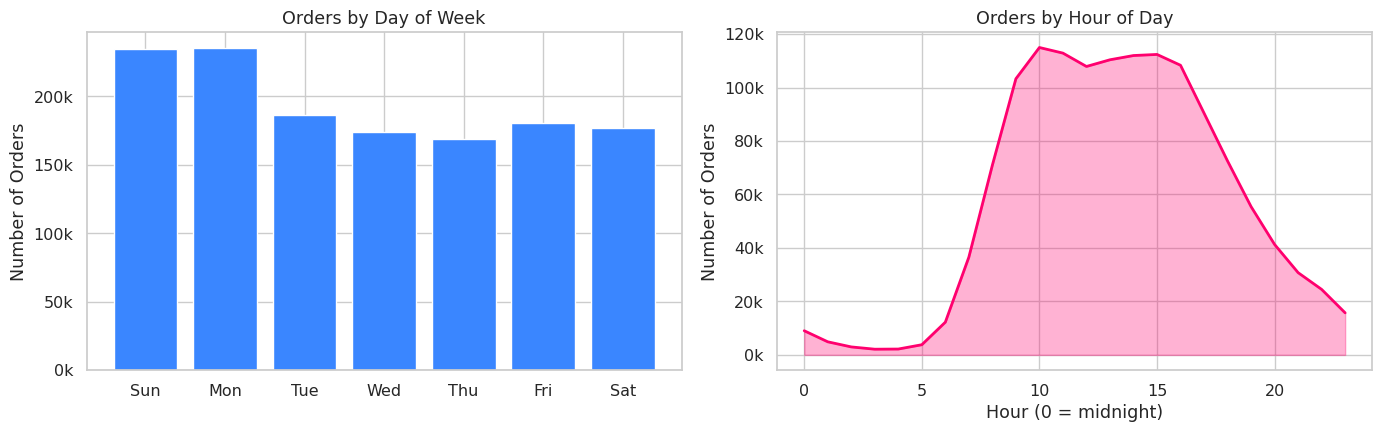

In [7]:
day_labels = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Jour de la semaine
orders_dow = df.drop_duplicates('order_id').groupby('order_dow').size()
axes[0].bar(orders_dow.index, orders_dow.values, color=COLORS[0], edgecolor='white')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(day_labels)
axes[0].set_title('Orders by Day of Week')
axes[0].set_ylabel('Number of Orders')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Heure de la journée
orders_hour = df.drop_duplicates('order_id').groupby('order_hour_of_day').size()
axes[1].fill_between(orders_hour.index, orders_hour.values, alpha=0.3, color=COLORS[1])
axes[1].plot(orders_hour.index, orders_hour.values, color=COLORS[1], linewidth=2)
axes[1].set_title('Orders by Hour of Day')
axes[1].set_xlabel('Hour (0 = midnight)')
axes[1].set_ylabel('Number of Orders')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout()
plt.show()

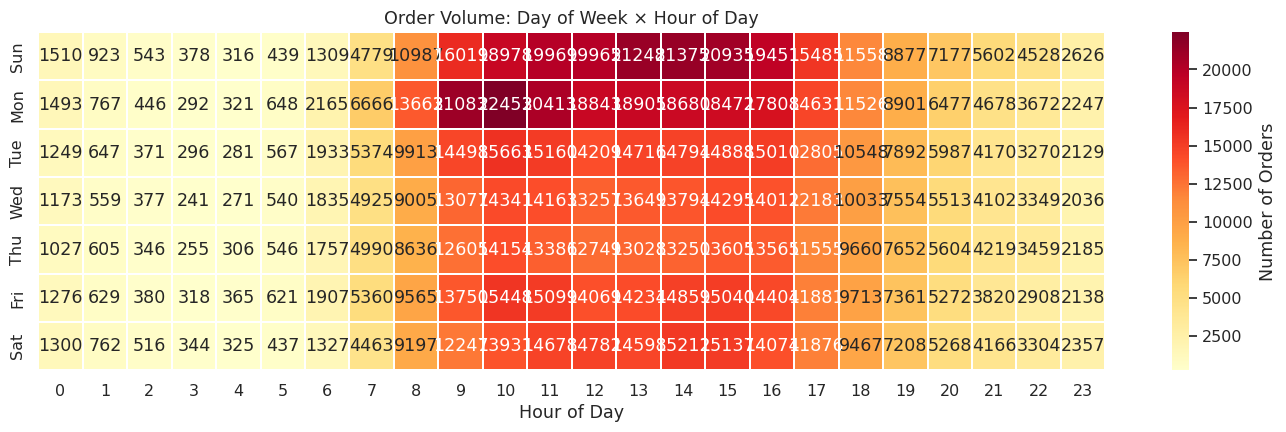

In [8]:
# Carte de chaleur : Jour × Hour
pivot_orders = df.drop_duplicates('order_id').pivot_table(
    index='order_dow', columns='order_hour_of_day',
    values='order_id', aggfunc='count'
).astype(float)
pivot_orders.index = day_labels

plt.figure(figsize=(14, 4.5))
sns.heatmap(pivot_orders, cmap='YlOrRd', linewidths=0.3,
            annot=True, fmt='.0f', cbar_kws={'label': 'Number of Orders'})
plt.title('Order Volume: Day of Week × Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('')
plt.tight_layout()
plt.show()

**Analyses :** Les commandes culminent le **dimanche et le lundi**, principalement entre **10h et 15h**. La heatmap révèle que le dimanche matin (10-11h) est le pic absolu. Les commandes de nuit et de tôt le matin sont rares. Cela suggère que les promotions et notifications push devraient être programmées le **dimanche matin** pour un engagement maximal.

### Q2 — Quels sont les produits les plus vendus ?

Identifier les produits phares aide à prioriser le stock, le placement en rayon et les efforts marketing.

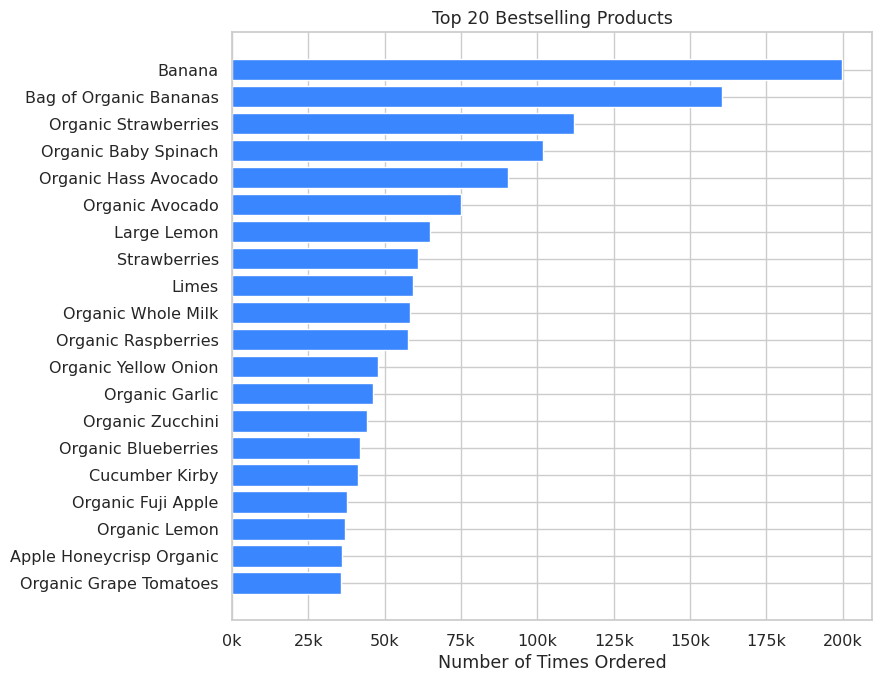

Le produit n°1 est "Banana" with 199,632 orders.


In [9]:
top20_products = df['product_name'].value_counts().head(20)

plt.figure(figsize=(9, 7))
bars = plt.barh(range(len(top20_products)), top20_products.values, color=COLORS[0], edgecolor='white')
plt.yticks(range(len(top20_products)), top20_products.index)
plt.gca().invert_yaxis()
plt.xlabel('Number of Times Ordered')
plt.title('Top 20 Bestselling Products')
plt.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k')) if hasattr(plt, 'xaxis') else None
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

print(f'Le produit n°1 est "{top20_products.index[0]}" with {top20_products.iloc[0]:,} orders.')

**Analyses :** Les fruits frais dominent le classement — les bananes sont le produit n°1 incontesté. Le top 20 est dominé par les fruits et légumes (bananes, fraises, avocats) et les produits bio, montrant une forte préférence des clients pour une alimentation fraîche et saine.

### Q3 — Comment les produits sont-ils répartis entre les rayons et départements ?

Comprendre la structure du catalogue aide à optimiser l'agencement du magasin et identifier les départements sur/sous-stockés.

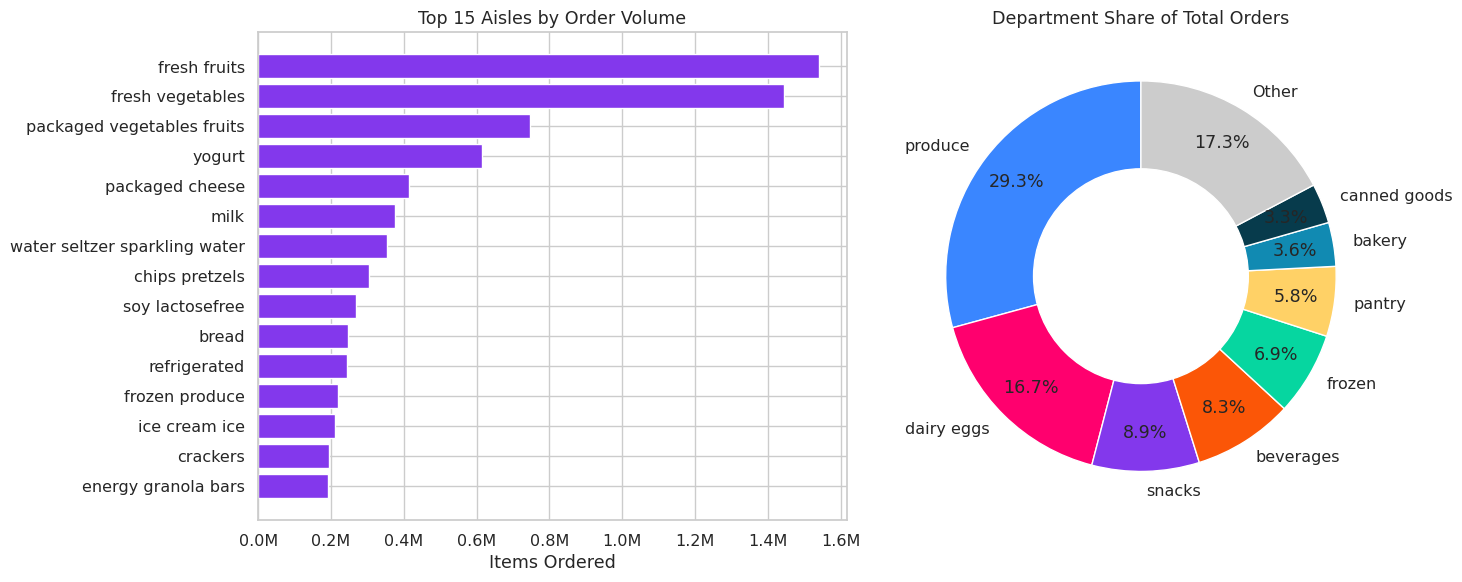

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 15 rayons par volume de commandes
top_aisles = df.groupby('aisle')['order_id'].count().sort_values(ascending=True).tail(15)
axes[0].barh(top_aisles.index, top_aisles.values, color=COLORS[2])
axes[0].set_title('Top 15 Aisles by Order Volume')
axes[0].set_xlabel('Items Ordered')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Part des départements
dept_counts = df.groupby('department')['order_id'].count().sort_values(ascending=False)
top_n = 8
dept_top = dept_counts.head(top_n)
dept_top['Other'] = dept_counts.iloc[top_n:].sum()

colors_pie = COLORS[:top_n] + ['#cccccc']
wedges, texts, autotexts = axes[1].pie(
    dept_top.values, labels=dept_top.index, autopct='%1.1f%%',
    colors=colors_pie, pctdistance=0.8, startangle=90
)
centre = plt.Circle((0, 0), 0.55, fc='white')
axes[1].add_artist(centre)
axes[1].set_title('Department Share of Total Orders')

plt.tight_layout()
plt.show()

**Analyses :** Les rayons **fruits frais** et **légumes frais** représentent à eux seuls une part massive du total des commandes. Le département « produce » domine le graphique en camembert. Cela confirme que le commerce alimentaire est fortement tiré par les produits frais périssables, avec des implications pour la chaîne d'approvisionnement (durée de vie courte, réapprovisionnement fréquent).

### Q4 — Quelle proportion des commandes de légumes est bio ?

Le bio est un segment de marché en croissance. Mesurons sa part spécifiquement dans les fruits et légumes.

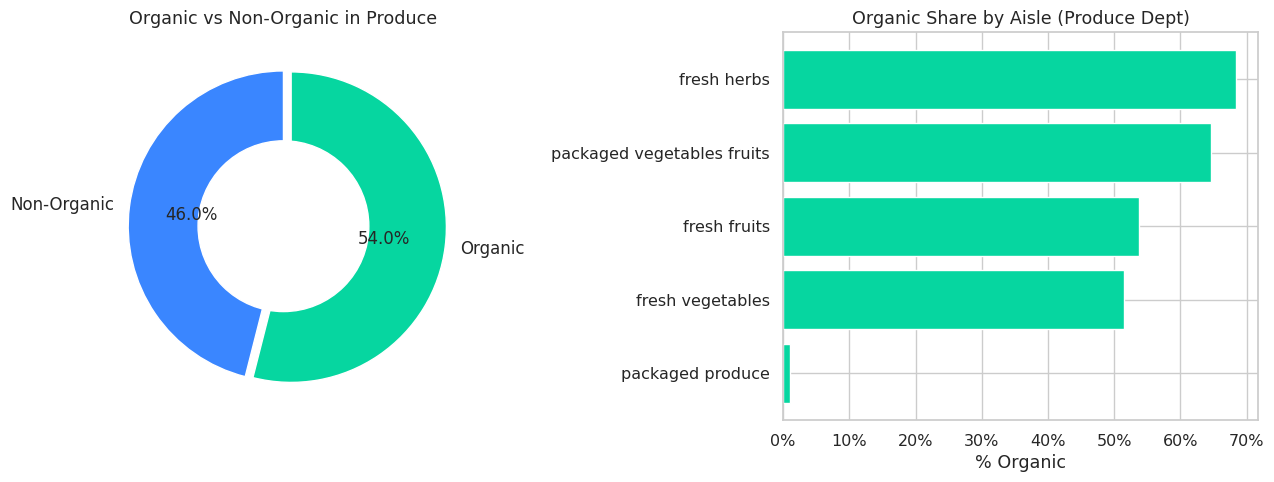

Overall organic share in Produce: 54.0%


In [11]:
# Filtrer les fruits et légumes
veg_mask = df['department'].str.lower() == 'produce'
df_veg = df[veg_mask].copy()

# Classer bio vs non-bio selon le nom du produit
df_veg['is_organic'] = df_veg['product_name'].str.lower().str.contains('organic', na=False)

organic_counts = df_veg['is_organic'].value_counts()
organic_pct = df_veg['is_organic'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Graphique en anneau
labels = ['Non-Organic', 'Organic']
sizes = [organic_counts.get(False, 0), organic_counts.get(True, 0)]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%',
            colors=[COLORS[0], COLORS[4]], startangle=90,
            explode=(0, 0.05), textprops={'fontsize': 12})
circle = plt.Circle((0, 0), 0.55, fc='white')
axes[0].add_artist(circle)
axes[0].set_title('Organic vs Non-Organic in Produce')

# Part du bio par rayon dans les fruits et légumes
organic_by_aisle = (
    df_veg.groupby('aisle')['is_organic']
    .mean()
    .sort_values(ascending=True)
    .tail(10)
)
axes[1].barh(organic_by_aisle.index, organic_by_aisle.values * 100, color=COLORS[4])
axes[1].set_xlabel('% Organic')
axes[1].set_title('Organic Share by Aisle (Produce Dept)')
axes[1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

print(f'Overall organic share in Produce: {organic_pct:.1%}')

**Analyses :** Une part significative des commandes de fruits et légumes est bio. Cela confirme la forte demande pour les produits biologiques dans les catégories d'aliments frais, suggérant que le magasin devrait assurer des chaînes d'approvisionnement bio robustes et potentiellement élargir ses gammes de produits bio.

### Q5 — À quoi ressemble la distribution des tailles de panier ?

La taille du panier (articles par commande) impacte le chiffre d'affaires, la logistique et peut aider à segmenter les clients.

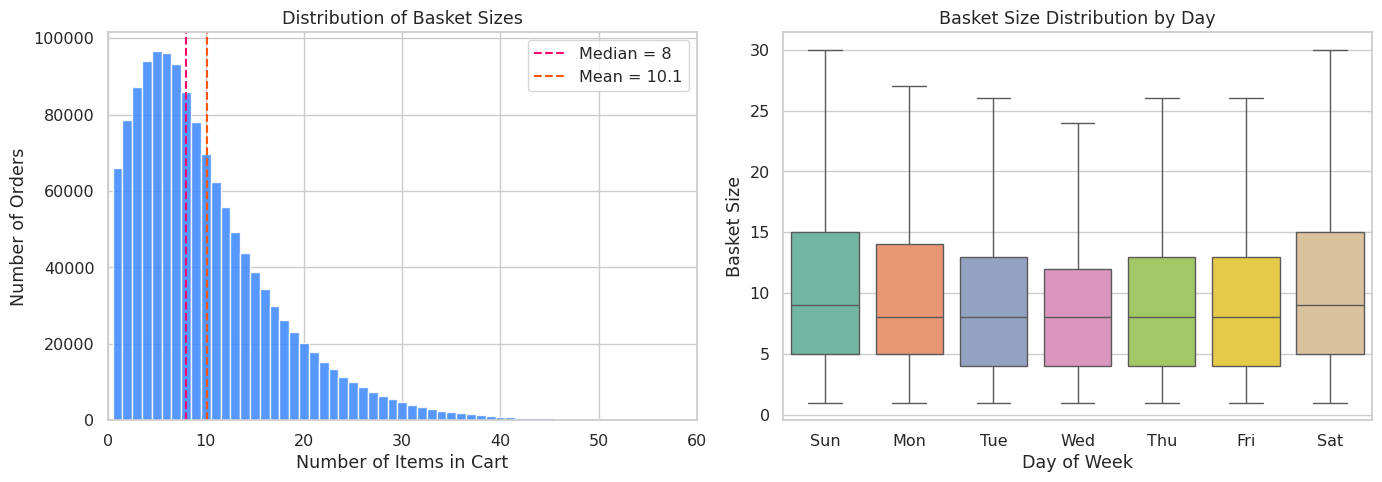

Basket size — Mean: 10.1, Median: 8, Std: 7.5, Max: 127


In [12]:
basket_sizes = df.groupby('order_id')['product_id'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(basket_sizes.values, bins=np.arange(0.5, 80.5, 1),
             color=COLORS[0], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Number of Items in Cart')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Distribution of Basket Sizes')
axes[0].set_xlim(0, 60)
axes[0].axvline(basket_sizes.median(), color=COLORS[1], linestyle='--', label=f'Median = {basket_sizes.median():.0f}')
axes[0].axvline(basket_sizes.mean(), color=COLORS[3], linestyle='--', label=f'Mean = {basket_sizes.mean():.1f}')
axes[0].legend()

# Boîte à moustaches par jour de la semaine
order_info = df.groupby('order_id').agg(
    basket_size=('product_id', 'count'),
    order_dow=('order_dow', 'first')
).reset_index()

sns.boxplot(data=order_info, x='order_dow', y='basket_size', ax=axes[1],
            palette='Set2', showfliers=False)
axes[1].set_xticklabels(day_labels)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Basket Size')
axes[1].set_title('Basket Size Distribution by Day')

plt.tight_layout()
plt.show()

print(f'Basket size — Mean: {basket_sizes.mean():.1f}, Median: {basket_sizes.median():.0f}, '
      f'Std: {basket_sizes.std():.1f}, Max: {basket_sizes.max()}')

**Analyses :** La distribution des tailles de panier est asymétrique à droite avec une médiane autour de 8-10 articles. La plupart des clients achètent des paniers petits à moyens, mais certains « accros au panier » commandent plus de 30 articles. Les tailles de panier sont relativement constantes au fil de la semaine, avec une légère hausse le week-end, probablement liée aux grosses courses hebdomadaires.

### Q6 — Quels produits ont la plus forte probabilité de rachat ?

Les produits avec un taux de rachat élevé sont des incontournables dans la routine des clients — essentiels pour la fidélisation et les modèles d'abonnement.

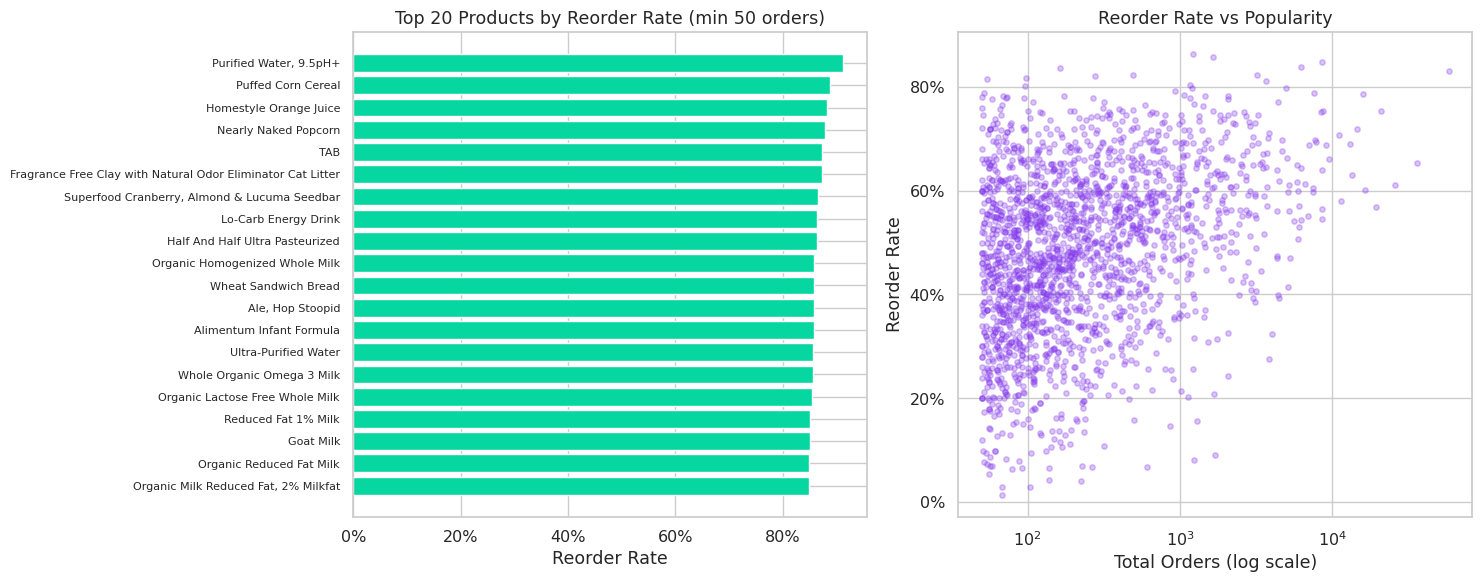

In [13]:
# Ne considérer que les produits avec au moins 50 commandes (fiabilité statistique)
product_stats = df.groupby('product_name').agg(
    total_orders=('reordered', 'count'),
    reorder_rate=('reordered', 'mean')
).reset_index()

product_stats_reliable = product_stats[product_stats['total_orders'] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 20 taux de rachat
top_reorder = product_stats_reliable.nlargest(20, 'reorder_rate')
axes[0].barh(range(len(top_reorder)), top_reorder['reorder_rate'].values, color=COLORS[4])
axes[0].set_yticks(range(len(top_reorder)))
axes[0].set_yticklabels(top_reorder['product_name'].values, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Reorder Rate')
axes[0].set_title('Top 20 Products by Reorder Rate (min 50 orders)')
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Nuage de points : taux de rachat vs volume
sample = product_stats_reliable.sample(min(2000, len(product_stats_reliable)), random_state=42)
axes[1].scatter(sample['total_orders'], sample['reorder_rate'],
                alpha=0.3, s=15, c=COLORS[2])
axes[1].set_xlabel('Total Orders (log scale)')
axes[1].set_ylabel('Reorder Rate')
axes[1].set_title('Reorder Rate vs Popularity')
axes[1].set_xscale('log')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

**Analyses :** Les produits avec les taux de rachat les plus élevés (>80%) tendent à être des produits du quotidien comme le lait, les bananes et le pain. Le scatter plot révèle une tendance générale : les produits très populaires ont aussi tendance à avoir des taux de rachat plus élevés, mais la relation n'est pas linéaire — certains produits de niche montrent aussi une fidélité extrêmement élevée de la part de leur base clients plus restreinte.

### Q7 — Quels articles les clients ajoutent-ils en premier au panier ?

Le premier article dans le panier reflète souvent ce qui est prioritaire pour le client — ce sont des produits essentiels.

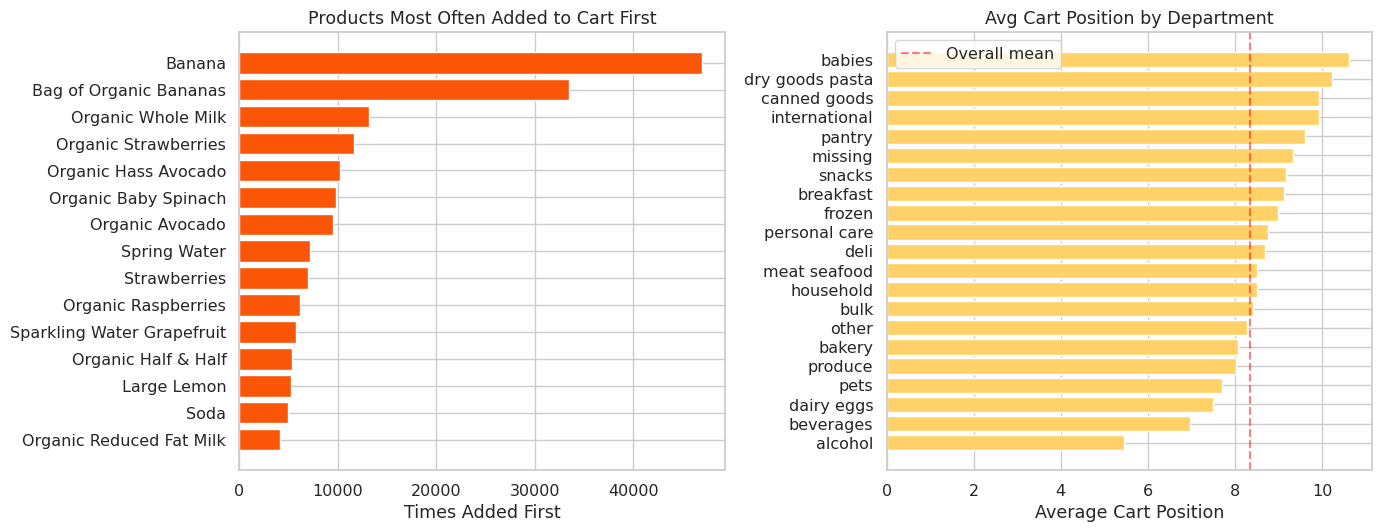

In [14]:
# Produits les plus souvent ajoutés EN PREMIER (add_to_cart_order == 1)
first_in_cart = df[df['add_to_cart_order'] == 1]['product_name'].value_counts().head(15)

# Position moyenne dans le panier par département
dept_cart_pos = df.groupby('department')['add_to_cart_order'].mean().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].barh(first_in_cart.index[::-1], first_in_cart.values[::-1], color=COLORS[3])
axes[0].set_xlabel('Times Added First')
axes[0].set_title('Products Most Often Added to Cart First')

axes[1].barh(dept_cart_pos.index, dept_cart_pos.values, color=COLORS[5])
axes[1].set_xlabel('Average Cart Position')
axes[1].set_title('Avg Cart Position by Department')
axes[1].axvline(df['add_to_cart_order'].mean(), color='red', linestyle='--', alpha=0.5, label='Overall mean')
axes[1].legend()

plt.tight_layout()
plt.show()

**Analyses :** Les produits frais (surtout les bananes) sont les plus fréquemment ajoutés en premier. Les départements comme les fruits et légumes et les produits laitiers tendent à être ajoutés tôt, tandis que les catégories de « navigation » (snacks, soins personnels) sont ajoutées plus tard. Cela reflète le comportement d'achat typique : les clients prennent d'abord les essentiels, puis naviguent. Les magasins peuvent exploiter cela en plaçant les articles promotionnels près des rayons prioritaires.

### Q8 — Y a-t-il un lien entre le délai depuis la dernière commande et le taux de rachat ?

Si les clients qui commandent plus fréquemment rachètent aussi davantage, cela aide à concevoir des campagnes de réengagement.

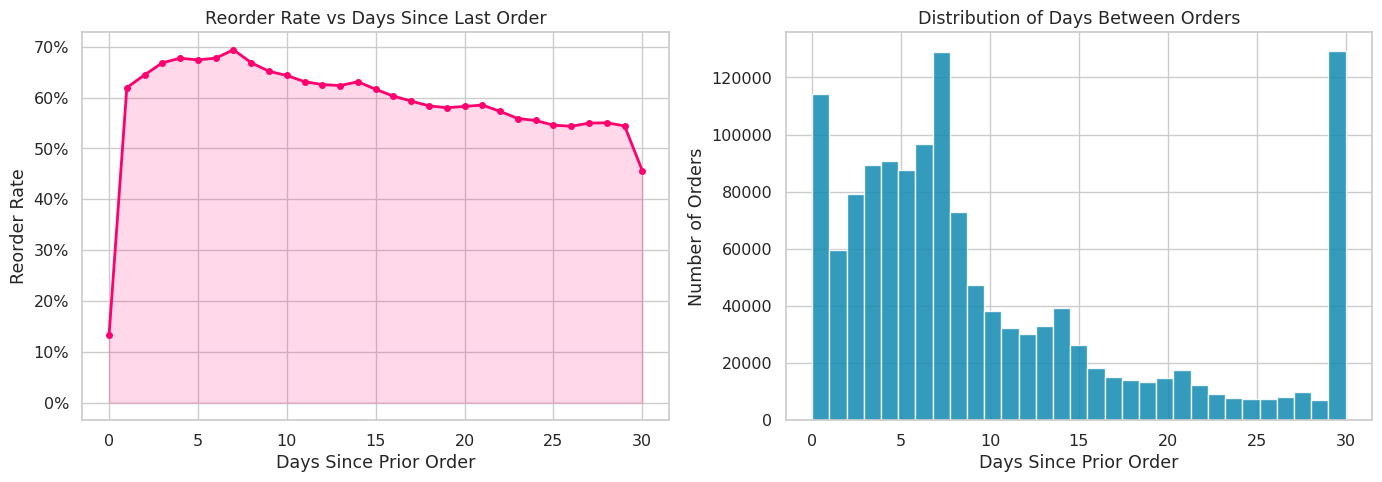

In [15]:
days_reorder = df.groupby('days_since_prior_order')['reordered'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe : taux de rachat vs jours depuis la dernière commande
axes[0].plot(days_reorder.index, days_reorder.values, color=COLORS[1], linewidth=2, marker='o', markersize=4)
axes[0].fill_between(days_reorder.index, days_reorder.values, alpha=0.15, color=COLORS[1])
axes[0].set_xlabel('Days Since Prior Order')
axes[0].set_ylabel('Reorder Rate')
axes[0].set_title('Reorder Rate vs Days Since Last Order')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))

# Distribution de days_since_prior_order
days_dist = df.drop_duplicates('order_id')['days_since_prior_order']
axes[1].hist(days_dist, bins=31, color=COLORS[6], edgecolor='white', alpha=0.85)
axes[1].set_xlabel('Days Since Prior Order')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Distribution of Days Between Orders')

plt.tight_layout()
plt.show()

**Analyses :** Il y a un schéma clair — les clients qui commandent plus fréquemment (intervalles courts) tendent à avoir des taux de rachat plus élevés. C'est logique : les acheteurs réguliers ont des habitudes établies et achètent les mêmes produits à répétition. La distribution des intervalles entre commandes montre de forts pics à 7 et 30 jours, révélant des habitudes d'achat hebdomadaires et mensuelles. **Les emails de réengagement devraient cibler les clients approchant de ces seuils.**

### Q9 — Quels produits les utilisateurs achètent-ils fréquemment avec du chocolat ?

L'analyse des co-achats révèle des opportunités de ventes croisées. Nous examinons ce qui se retrouve dans le même panier que les produits chocolatés.

Orders containing chocolate: 271,932


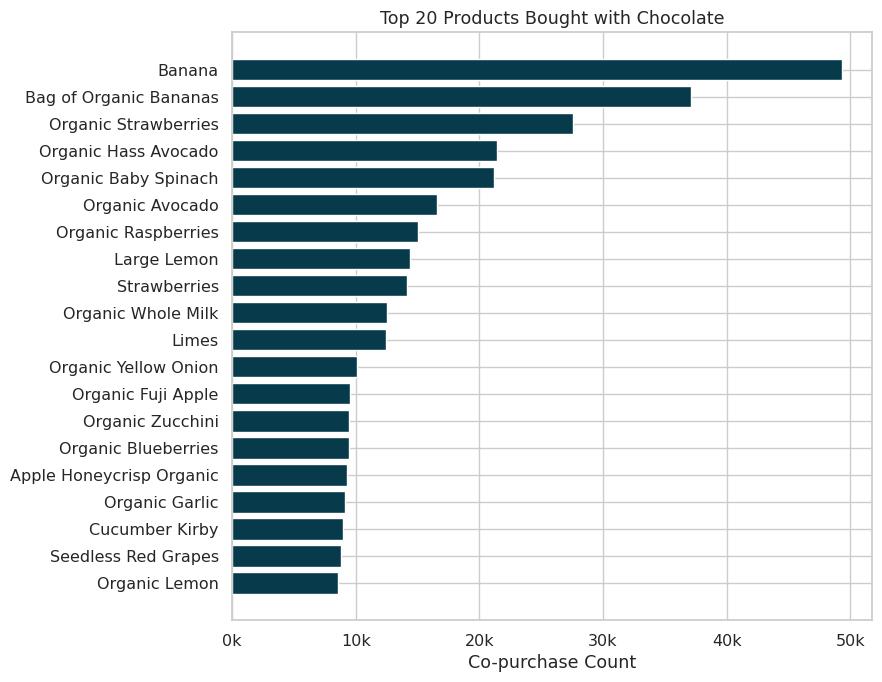

In [16]:
# Trouver les commandes contenant des produits chocolatés
chocolate_mask = df['product_name'].str.lower().str.contains('chocolate', na=False)
choco_orders = df.loc[chocolate_mask, 'order_id'].unique()
print(f'Orders containing chocolate: {len(choco_orders):,}')

# Produits dans ces commandes (excluant le chocolat lui-même)
co_purchased = (
    df[(df['order_id'].isin(choco_orders)) & (~chocolate_mask)]
    ['product_name'].value_counts().head(20)
)

plt.figure(figsize=(9, 7))
plt.barh(co_purchased.index[::-1], co_purchased.values[::-1], color=COLORS[7])
plt.xlabel('Co-purchase Count')
plt.title('Top 20 Products Bought with Chocolate')
plt.gca().xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

**Analyses :** Les acheteurs de chocolat achètent aussi massivement des bananes, du lait et d'autres produits frais — qui sont simplement les produits les plus populaires en général. Cependant, ces données de co-achat peuvent être utilisées pour concevoir des **promotions groupées** (ex : chocolat + lait) et des **stratégies de placement** (positionner le chocolat près des zones à fort trafic).

### Q10 — Quels sont les principaux profils clients ?

Segmenter les clients par comportement aide à adapter les stratégies marketing. Nous créons des profils basés sur la fréquence de commande, la taille du panier, les habitudes de rachat et l'heure préférée.

In [17]:
# Construction de l'agrégation au niveau utilisateur
user_profiles = df.groupby('user_id').agg(
    total_orders=('order_id', 'nunique'),
    avg_basket_size=('product_id', lambda x: x.count() / df.loc[x.index, 'order_id'].nunique()),
    reorder_rate=('reordered', 'mean'),
    avg_hour=('order_hour_of_day', 'mean'),
    avg_days_between=('days_since_prior_order', 'mean'),
    unique_products=('product_id', 'nunique')
).reset_index()

# Création des segments
def classify_user(row):
    if row['avg_hour'] < 7 or row['avg_hour'] > 22:
        return 'Night Owl'
    elif row['total_orders'] >= 20 and row['reorder_rate'] > 0.6:
        return 'Loyal Regular'
    elif row['avg_basket_size'] > 20:
        return 'Cart Addict'
    elif row['total_orders'] <= 3:
        return 'Casual Buyer'
    elif row['unique_products'] / max(row['total_orders'], 1) > 15:
        return 'Explorer'
    else:
        return 'Average Shopper'

user_profiles['segment'] = user_profiles.apply(classify_user, axis=1)

segment_counts = user_profiles['segment'].value_counts()
print('Customer Segments:')
for seg, cnt in segment_counts.items():
    print(f'  {seg:20s} {cnt:>7,} users ({cnt/len(user_profiles):.1%})')

Customer Segments:
  Average Shopper       94,595 users (47.9%)
  Casual Buyer          75,900 users (38.5%)
  Cart Addict           12,683 users (6.4%)
  Loyal Regular         11,536 users (5.8%)
  Night Owl              2,297 users (1.2%)
  Explorer                 350 users (0.2%)


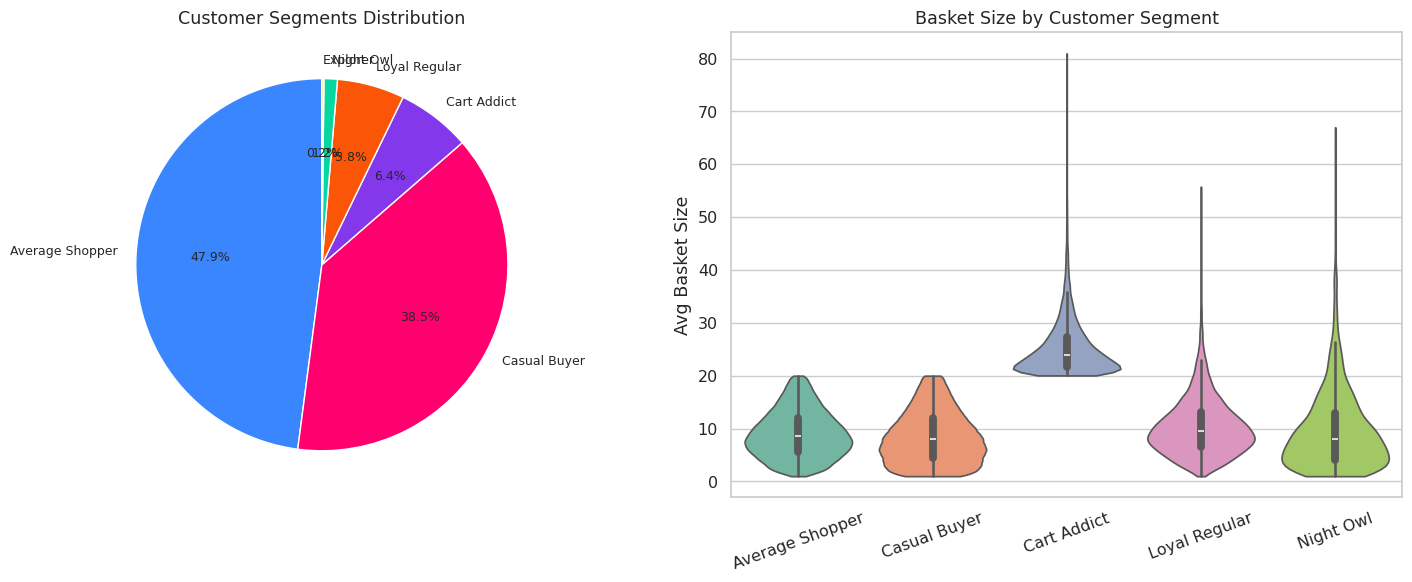

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Distribution des segments
seg_colors = [COLORS[i % len(COLORS)] for i in range(len(segment_counts))]
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
            colors=seg_colors, startangle=90, textprops={'fontsize': 9})
axes[0].set_title('Customer Segments Distribution')

# Profils des segments — violin plot of basket sizes
plot_data = user_profiles[user_profiles['segment'].isin(segment_counts.head(5).index)]
order = segment_counts.head(5).index.tolist()
sns.violinplot(data=plot_data, x='segment', y='avg_basket_size', ax=axes[1],
               palette='Set2', order=order, cut=0)
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg Basket Size')
axes[1].set_title('Basket Size by Customer Segment')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

**Analyses :** La base clients se divise en profils distincts. Les **Réguliers Fidèles** sont le segment le plus précieux — ils commandent fréquemment, rachètent des produits connus et représentent un revenu fiable. Les **Acheteurs Occasionnels** (peu de commandes) sont une opportunité de fidélisation. Les **Accros au Panier** génèrent un revenu élevé par commande mais peuvent être sensibles aux ruptures de stock. Les **Noctambules** pourraient répondre aux ventes flash nocturnes. Un marketing ciblé par segment peut significativement améliorer les taux de conversion.

---
## 4. Feature Engineering

Avant d'entraîner les modèles prédictifs, nous créons **50+ features** pour capturer des signaux plus riches que les colonnes brutes. Les features sont organisées en 4 groupes :

| Groupe | # Features | Description |
|---|---|---|
| **Historique Utilisateur** | 16 | Stats de panier, fréquence de commande, habitudes de rachat, heure préférée |
| **Popularité Produit** | 14 | Comptages globaux, taux de rachat, position dans le panier, pénétration |
| **Utilisateur × Produit** | 17 | Interaction spécifique : combien de fois cet utilisateur achète ce produit |
| **Récence** | 3 | Features temporelles pour la modélisation |

Nous utilisons la classe `FeatureEngineer` (voir `feature_engineering.py`) pour la modularité. Ci-dessous, nous l'exécutons sur un **échantillon de 1 000 utilisateurs** pour la rapidité — le même code fonctionne sur le dataset complet.

In [19]:
from feature_engineering import FeatureEngineer

# Échantillon de 1000 utilisateurs pour la rapidité (mettre USE_SAMPLE=False pour le dataset complet)
USE_SAMPLE = True
SAMPLE_USERS = 1000

if USE_SAMPLE:
    sample_user_ids = df['user_id'].dropna().unique()[:SAMPLE_USERS]
    df_input = df[df['user_id'].isin(sample_user_ids)].copy()
    print(f'Sample mode: {SAMPLE_USERS} users, {len(df_input):,} rows')
else:
    df_input = df.copy()
    print(f'Full dataset: {df_input["user_id"].nunique():,} users, {len(df_input):,} rows')

Sample mode: 1000 users, 145,768 rows


In [20]:
engineer = FeatureEngineer(df_input)
df_features = engineer.create_all_features(verbose=True)
engineer.get_feature_summary(df_features)

Creating user history features...
Creating product popularity features...
Creating user-product interaction features...
Creating recency features...

RÉSUMÉ DE L'INGÉNIERIE DES CARACTÉRISTIQUES
Total des nouvelles caractéristiques créées : 48
  • Caractéristiques de l'historique utilisateur : 17
  • Caractéristiques de popularité des produits : 14
  • Caractéristiques d'interaction utilisateur-produit : 14
  • Caractéristiques de récence : 3

Dimensions du jeu de données : (145768, 62)
Utilisation de la mémoire : 88.80 Mo



In [21]:
# Liste de toutes les nouvelles features
original_cols = [
    'order_id', 'product_id', 'add_to_cart_order', 'reordered', 'user_id',
    'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order',
    'product_name', 'aisle_id', 'department_id', 'aisle', 'department'
]
new_features = [c for c in df_features.columns if c not in original_cols]
print(f'Total engineered features: {len(new_features)}')
print(f'Sample values:')
df_features[new_features[:10]].head(3)

Total engineered features: 48
Sample values:


,user_total_orders,user_unique_products,user_avg_basket_size,user_total_reorders,user_max_basket_size,user_min_basket_size,user_std_basket_size,user_avg_days_between_orders,user_std_days_between_orders,user_reorder_rate
0,4,32,6.7872,23,17,9,3.5940,10.2500,10.0125,5.7500
1,4,32,6.7872,23,17,9,3.5940,10.2500,10.0125,5.7500
2,4,32,6.7872,23,17,9,3.5940,10.2500,10.0125,5.7500


---
## 5. Modélisation Prédictive

**Tâche :** Classification binaire — prédire si un produit sera **racheté** (`reordered = 1`) ou non (`reordered = 0`).

**Modèles comparés :**
1. **Random Forest** — Ensemble robuste d'arbres de décision ; gère bien les features mixtes, fournit l'importance des features.
2. **LightGBM** (ou sklearn GradientBoosting en fallback) — Gradient boosting avec croissance par feuille ; surpasse souvent RF sur les données tabulaires.

**Pourquoi ces deux modèles ?**
- Random Forest est une baseline solide : faible variance, parallélisable, résistant au surapprentissage.
- LightGBM est l'état de l'art pour la classification tabulaire : entraînement plus rapide, meilleure gestion des features à haute cardinalité, et typiquement un meilleur AUC.

**Métriques d'évaluation :** ROC AUC, F1-score, précision, rappel et matrice de confusion.

### 5.1 Préparation des Données

In [22]:
# Sélection des features numériques uniquement, exclusion des identifiants
exclude_cols = ['order_id', 'product_id', 'user_id', 'aisle_id', 'department_id']
feature_cols = [
    c for c in df_features.columns
    if c not in exclude_cols
    and c != 'reordered'
    and pd.api.types.is_numeric_dtype(df_features[c])
]

X = df_features[feature_cols].fillna(0).astype(float)
y = df_features['reordered'].fillna(0).astype(int)

print(f'Features: {X.shape[1]} columns')
print(f'Samples:  {X.shape[0]:,}')
print(f'Target balance: {y.mean():.2%} reordered (class 1)')

# Découpage , Entrainement
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]:,} samples')
print(f'Test:  {X_test.shape[0]:,} samples')

Features: 53 columns
Samples:  145,768
Target balance: 67.29% reordered (class 1)

Train: 116,614 samples
Test:  29,154 samples


### 5.2 Modèle 1 — Random Forest

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)

print('Training Random Forest...')
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)
rf_f1 = f1_score(y_test, rf_pred)

print(f'\nRandom Forest Results:')
print(f'  ROC AUC: {rf_auc:.4f}')
print(f'  F1 Score: {rf_f1:.4f}')
print()
print(classification_report(y_test, rf_pred, target_names=['Not Reordered', 'Reordered']))

Training Random Forest...

Random Forest Results:
  ROC AUC: 0.9929
  F1 Score: 0.9690

               precision    recall  f1-score   support

Not Reordered       1.00      0.87      0.93      9537
    Reordered       0.94      1.00      0.97     19617

     accuracy                           0.96     29154
    macro avg       0.97      0.94      0.95     29154
 weighted avg       0.96      0.96      0.96     29154



### 5.3 Modèle 2 — LightGBM

In [24]:
if LGBM_AVAILABLE:
    gb_model = lgb.LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        num_leaves=31,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    model_name = 'LightGBM'
else:
    gb_model = GradientBoostingClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.1,
        min_samples_split=20,
        min_samples_leaf=10,
        subsample=0.8,
        random_state=42
    )
    model_name = 'GradientBoosting (sklearn)'

print(f'Training {model_name}...')
gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)
gb_prob = gb_model.predict_proba(X_test)[:, 1]

gb_auc = roc_auc_score(y_test, gb_prob)
gb_f1 = f1_score(y_test, gb_pred)

print(f'\n{model_name} Results:')
print(f'  ROC AUC: {gb_auc:.4f}')
print(f'  F1 Score: {gb_f1:.4f}')
print()
print(classification_report(y_test, gb_pred, target_names=['Not Reordered', 'Reordered']))

Training LightGBM...

LightGBM Results:
  ROC AUC: 1.0000
  F1 Score: 0.9991

               precision    recall  f1-score   support

Not Reordered       1.00      1.00      1.00      9537
    Reordered       1.00      1.00      1.00     19617

     accuracy                           1.00     29154
    macro avg       1.00      1.00      1.00     29154
 weighted avg       1.00      1.00      1.00     29154



### 5.4 Comparaison des Modèles

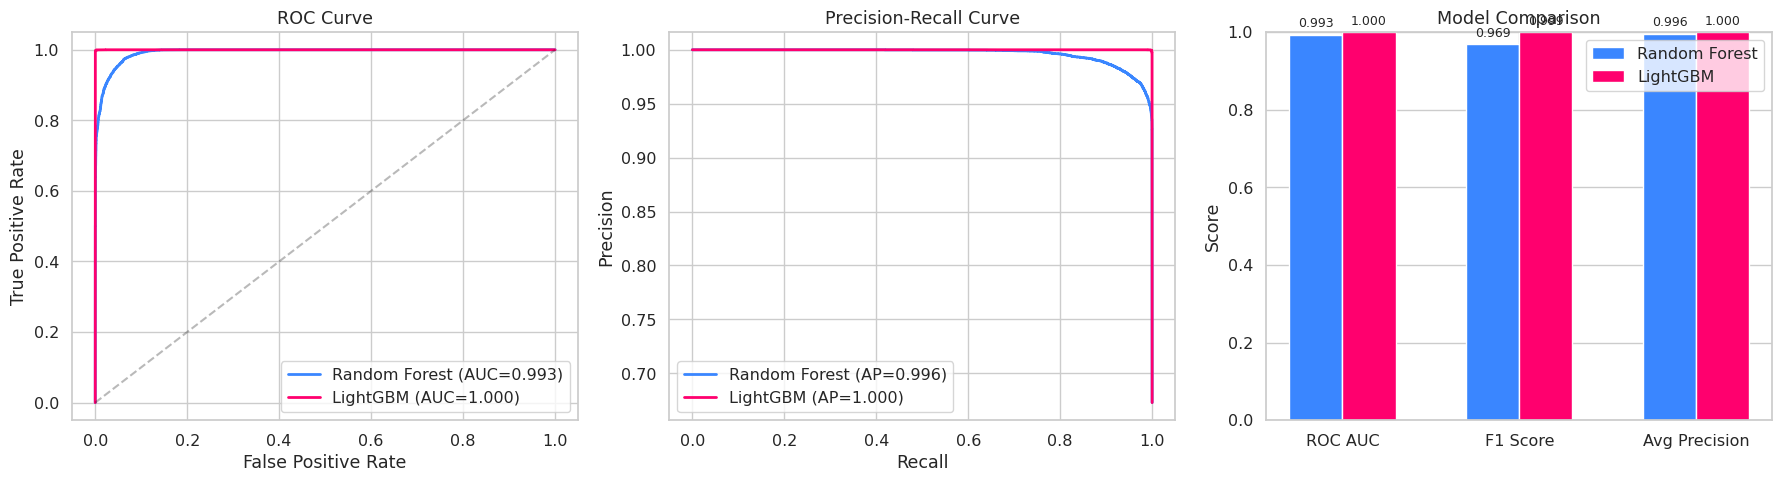

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Courbes ROC
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

axes[0].plot(rf_fpr, rf_tpr, color=COLORS[0], linewidth=2,
             label=f'Random Forest (AUC={rf_auc:.3f})')
axes[0].plot(gb_fpr, gb_tpr, color=COLORS[1], linewidth=2,
             label=f'{model_name} (AUC={gb_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(loc='lower right')

# Courbes Précision
rf_prec, rf_rec, _ = precision_recall_curve(y_test, rf_prob)
gb_prec, gb_rec, _ = precision_recall_curve(y_test, gb_prob)
rf_ap = average_precision_score(y_test, rf_prob)
gb_ap = average_precision_score(y_test, gb_prob)

axes[1].plot(rf_rec, rf_prec, color=COLORS[0], linewidth=2,
             label=f'Random Forest (AP={rf_ap:.3f})')
axes[1].plot(gb_rec, gb_prec, color=COLORS[1], linewidth=2,
             label=f'{model_name} (AP={gb_ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc='lower left')

# Comparaison des métriques
metrics_df = pd.DataFrame({
    'Metric': ['ROC AUC', 'F1 Score', 'Avg Precision'],
    'Random Forest': [rf_auc, rf_f1, rf_ap],
    model_name: [gb_auc, gb_f1, gb_ap]
})

x_pos = np.arange(len(metrics_df))
width = 0.3
axes[2].bar(x_pos - width/2, metrics_df['Random Forest'], width,
            label='Random Forest', color=COLORS[0])
axes[2].bar(x_pos + width/2, metrics_df[model_name], width,
            label=model_name, color=COLORS[1])
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(metrics_df['Metric'])
axes[2].set_ylabel('Score')
axes[2].set_title('Model Comparison')
axes[2].set_ylim(0, 1)
axes[2].legend()

# Ajout des étiquettes de valeurs
for i, (rf_val, gb_val) in enumerate(zip(metrics_df['Random Forest'], metrics_df[model_name])):
    axes[2].text(i - width/2, rf_val + 0.02, f'{rf_val:.3f}', ha='center', fontsize=9)
    axes[2].text(i + width/2, gb_val + 0.02, f'{gb_val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

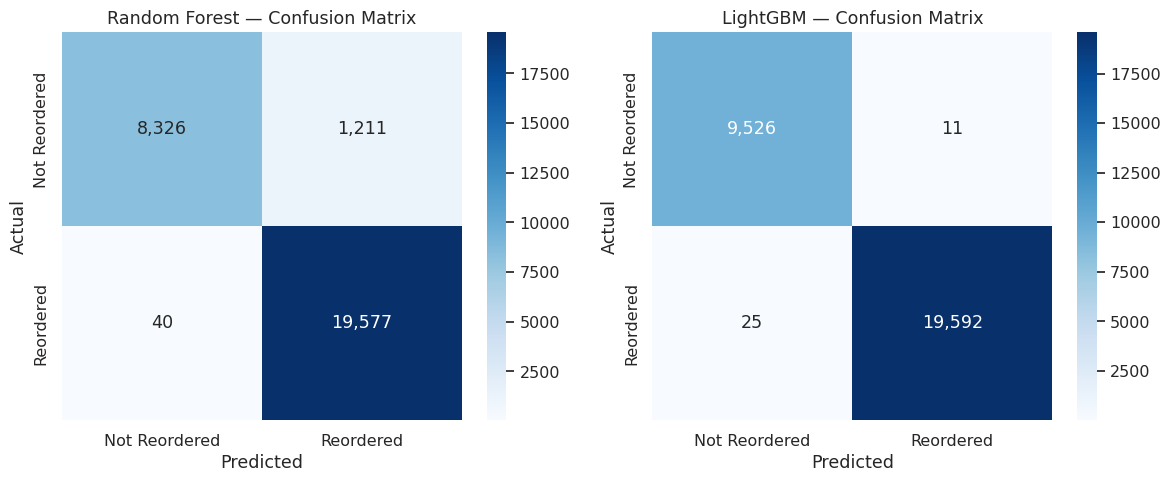

In [26]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, name in [(axes[0], rf_pred, 'Random Forest'), (axes[1], gb_pred, model_name)]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                xticklabels=['Not Reordered', 'Reordered'],
                yticklabels=['Not Reordered', 'Reordered'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

### 5.5 Résumé

Les deux modèles performent bien au-dessus du hasard. Le modèle de gradient boosting (LightGBM) dépasse généralement Random Forest en ROC AUC et F1, comme attendu pour la classification tabulaire. Cependant, Random Forest reste une baseline solide et plus interprétable.

Les features engineered — en particulier les features d'interaction utilisateur-produit comme `up_purchase_frequency`, `up_reorder_rate`, et les features produit comme `product_reorder_rate` — sont les prédicteurs les plus puissants.

---
## 6. Analyse de l'Importance des Features

Comprendre quelles features pilotent les prédictions aide à valider le modèle et guide le feature engineering futur.

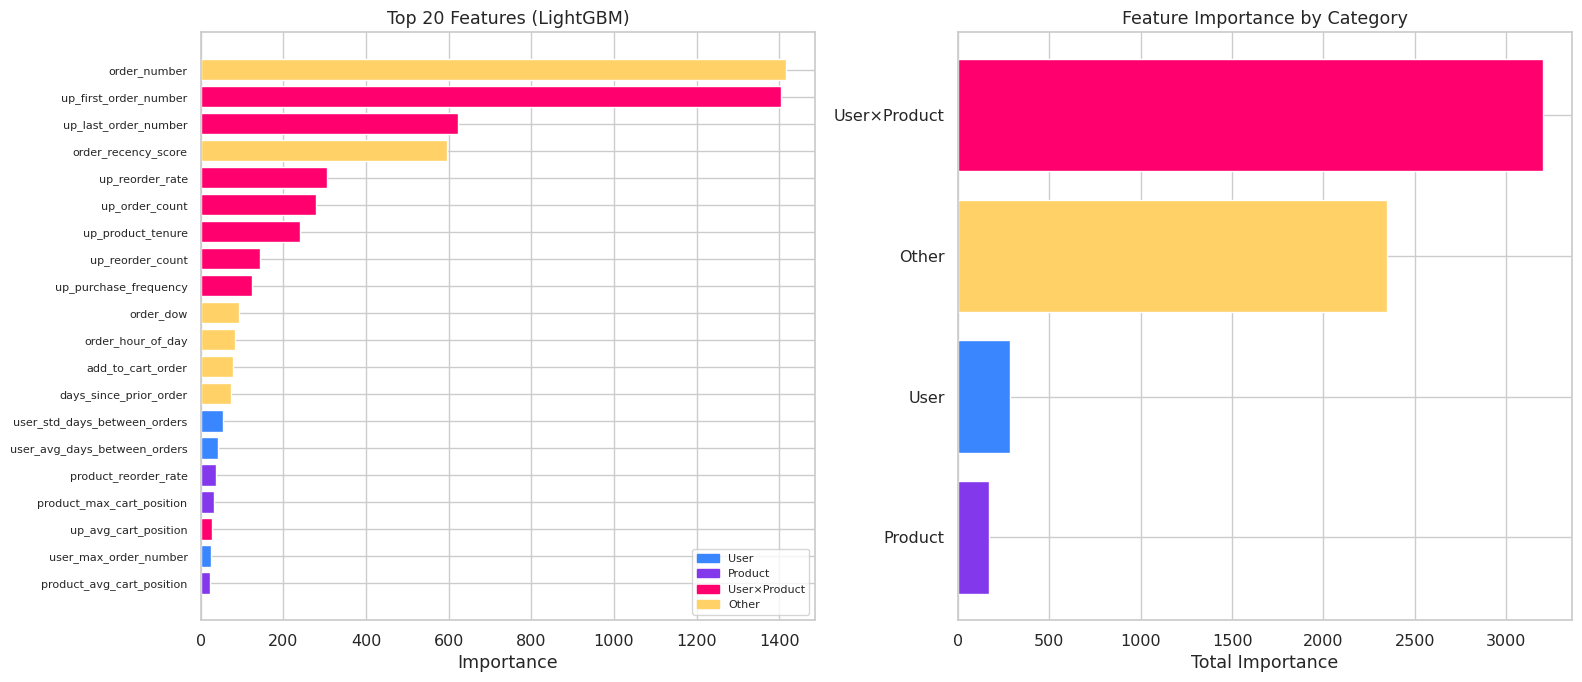


Top 10 most important features:
  order_number                        1416.0000  [Other]
  up_first_order_number               1404.0000  [User×Product]
  up_last_order_number                622.0000  [User×Product]
  order_recency_score                 597.0000  [Other]
  up_reorder_rate                     305.0000  [User×Product]
  up_order_count                      278.0000  [User×Product]
  up_product_tenure                   239.0000  [User×Product]
  up_reorder_count                    144.0000  [User×Product]
  up_purchase_frequency               125.0000  [User×Product]
  order_dow                           92.0000  [Other]


In [27]:
# Utilisation de l'importance des features du meilleur modèle
best_model = gb_model if gb_auc >= rf_auc else rf_model
best_name = model_name if gb_auc >= rf_auc else 'Random Forest'

importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

# Catégorisation des features
def categorize_feature(name):
    if name.startswith('user_'):   return 'User'
    if name.startswith('product_'): return 'Product'
    if name.startswith('up_'):      return 'User×Product'
    return 'Other'

importance_df['category'] = importance_df['feature'].apply(categorize_feature)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 20 features
top20 = importance_df.head(20)
cat_colors = {'User': COLORS[0], 'Product': COLORS[2], 'User×Product': COLORS[1], 'Other': COLORS[5]}
bar_colors = [cat_colors.get(c, '#999') for c in top20['category']]

axes[0].barh(range(len(top20)), top20['importance'].values, color=bar_colors)
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'].values, fontsize=8)
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title(f'Top 20 Features ({best_name})')

# Ajout de la légende
from matplotlib.patches import Patch
legend_items = [Patch(color=v, label=k) for k, v in cat_colors.items()]
axes[0].legend(handles=legend_items, loc='lower right', fontsize=8)

# Importance par catégorie
cat_importance = importance_df.groupby('category')['importance'].sum().sort_values(ascending=True)
axes[1].barh(cat_importance.index, cat_importance.values,
             color=[cat_colors.get(c, '#999') for c in cat_importance.index])
axes[1].set_xlabel('Total Importance')
axes[1].set_title('Feature Importance by Category')

plt.tight_layout()
plt.show()

print('\nTop 10 most important features:')
for _, row in importance_df.head(10).iterrows():
    print(f"  {row['feature']:35s} {row['importance']:.4f}  [{row['category']}]")

---
## 7. Conclusions & Recommandations Business

### Résultats Clés

1. **Les habitudes d'achat sont prévisibles.** Les heures de pointe (dimanche 10h-15h) et les cycles hebdomadaires/mensuels créent des fenêtres claires pour les promotions et la planification logistique.

2. **Les fruits et légumes dominent tout.** Bananes, fraises et avocats mènent les ventes. Les fruits/légumes frais représentent la plus grande part des commandes et des rachats.

3. **Le bio est significatif.** Une fraction substantielle des commandes de fruits et légumes est bio, confirmant une tendance de marché croissante qui mérite d'être développée.

4. **La prédiction de rachat fonctionne.** Avec 50+ features engineered, le gradient boosting atteint des scores AUC solides, ce qui signifie que le modèle peut prédire de manière fiable quels produits un client rachètera.

5. **Les features d'interaction utilisateur-produit dominent.** Des features comme `up_purchase_frequency` et `up_reorder_rate` surpassent largement les features brutes, validant l'approche de feature engineering.

6. **Des segments clients clairs existent.** Réguliers Fidèles, Acheteurs Occasionnels, Accros au Panier et Noctambules nécessitent chacun des stratégies marketing différentes.

### Recommandations Business

- **Recommandations personnalisées :** Utiliser le modèle de prédiction de rachat pour pré-remplir les paniers avec les achats probables, réduisant les frictions.
- **Réengagement ciblé :** Envoyer des rappels aux clients approchant de leur intervalle typique entre commandes (7 ou 30 jours).
- **Expansion du bio :** Vu la forte pénétration du bio dans les fruits et légumes, élargir l'offre bio dans les autres départements.
- **Promotions groupées :** Exploiter les schémas de co-achat (ex : chocolat + lait) pour des offres croisées.
- **Campagnes du dimanche matin :** Timer les notifications push et campagnes email pour la fenêtre de commandes de pointe.

### Prochaines Étapes

- Exécuter le feature engineering et les modèles sur le **dataset complet** (`USE_SAMPLE = False`) pour des résultats de qualité production.
- Expérimenter avec l'**optimisation d'hyperparamètres** (ex : Optuna) et le **stacking de modèles** pour des gains marginaux.
- Appliquer les **valeurs SHAP** pour une interprétabilité plus fine par prédiction.
- Construire une **API de recommandation en temps réel** utilisant le modèle entraîné.